In [1]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import cv2
import os
import shutil
import pathlib
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, models, transforms, utils
from torchvision.transforms import v2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torchvision.datasets import ImageFolder
import random
import torchsummary
from PIL import Image
from pathlib import Path
import pandas as pd
import numpy as np


# Handling images
from PIL import Image
import matplotlib.pyplot as plt

# Handling paths

import time

# Pytorch essentials
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torchvision.datasets import ImageFolder
import torchsummary



# Pytorch essentials for datasets.
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# Pytorch way of data augmentation.
import torchvision
from torchvision import datasets, models, transforms, utils
from torchvision.transforms import v2

import cv2
import os
from glob import glob
from tqdm import tqdm
import shutil
from sklearn.model_selection import train_test_split
import seaborn as sns

In [20]:
df = pd.read_csv('Chest_xray_Corona_Metadata.csv')
df


,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
0,0,IM-0128-0001.jpeg,Normal,TRAIN,NaN,NaN
1,1,IM-0127-0001.jpeg,Normal,TRAIN,NaN,NaN
2,2,IM-0125-0001.jpeg,Normal,TRAIN,NaN,NaN
3,3,IM-0122-0001.jpeg,Normal,TRAIN,NaN,NaN
4,4,IM-0119-0001.jpeg,Normal,TRAIN,NaN,NaN
...,...,...,...,...,...,...
5905,5928,person1637_virus_2834.jpeg,Pnemonia,TEST,NaN,Virus
5906,5929,person1635_virus_2831.jpeg,Pnemonia,TEST,NaN,Virus
5907,5930,person1634_virus_2830.jpeg,Pnemonia,TEST,NaN,Virus
5908,5931,person1633_virus_2829.jpeg,Pnemonia,TEST,NaN,Virus


In [ ]:
# import csv


# with open('Chest_xray_Corona_Metadata.csv', mode="r", newline='') as infile, open("new_file.csv", mode="w", newline='') as outfile:
#     reader = csv.reader(infile)
#     writer = csv.writer(outfile)

#     for row in reader:
#         # Replace 3rd column (index 2): Normal/Pneumonia
#         if row[2] == "Normal":
#             row[2] = "0"
#         elif row[2] == "Pneumonia":
#             row[2] = "1"

#         # Replace 6th column (index 5): bacteria/Virus
#         if row[5] == "bacteria":
#             row[5] = "0"
#         elif row[5] == "Virus":
#             row[5] = "1"


#         writer.writerow(row)

# data= pd.read_csv('new_file.csv')

In [21]:
# Split based on the 'split' column
train = df[df['Dataset_type'] == 'TRAIN']
test = df[df['Dataset_type'] == 'TEST']

# Optional: Save them to new CSV files
train.to_csv('train_data.csv', index=False)
test.to_csv('test_data.csv', index=False)

In [31]:
#Handling missing values train csv file 
train['Label_1_Virus_category'] = train['Label_1_Virus_category'].fillna('None')
train['Label_2_Virus_category'] = train['Label_2_Virus_category'].fillna('None')
#drop colums with "Stress-Smoking" 
train = train[train['Label_1_Virus_category'] != 'Stress-Smoking']
#train['Label_2_Virus_category'] = train['Label_2_Virus_category'].replace({'None': 0, 'COVID-19': 1, 'SARS': 2, 'MERS': 3})
train

C:\Users\BT_Lab\AppData\Local\Temp\ipykernel_18520\2726777037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Label_1_Virus_category'] = train['Label_1_Virus_category'].fillna('None')
C:\Users\BT_Lab\AppData\Local\Temp\ipykernel_18520\2726777037.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Label_2_Virus_category'] = train['Label_2_Virus_category'].fillna('None')


,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
0,0,IM-0128-0001.jpeg,Normal,TRAIN,None,None
1,1,IM-0127-0001.jpeg,Normal,TRAIN,None,None
2,2,IM-0125-0001.jpeg,Normal,TRAIN,None,None
3,3,IM-0122-0001.jpeg,Normal,TRAIN,None,None
4,4,IM-0119-0001.jpeg,Normal,TRAIN,None,None
...,...,...,...,...,...,...
5281,5304,1-s2.0-S0929664620300449-gr2_lrg-c.jpg,Pnemonia,TRAIN,COVID-19,Virus
5282,5305,1-s2.0-S0929664620300449-gr2_lrg-b.jpg,Pnemonia,TRAIN,COVID-19,Virus
5283,5306,1-s2.0-S0929664620300449-gr2_lrg-a.jpg,Pnemonia,TRAIN,COVID-19,Virus
5284,5307,1-s2.0-S0140673620303706-fx1_lrg.jpg,Pnemonia,TRAIN,COVID-19,Virus


<Axes: xlabel='Label_1_Virus_category', ylabel='count'>

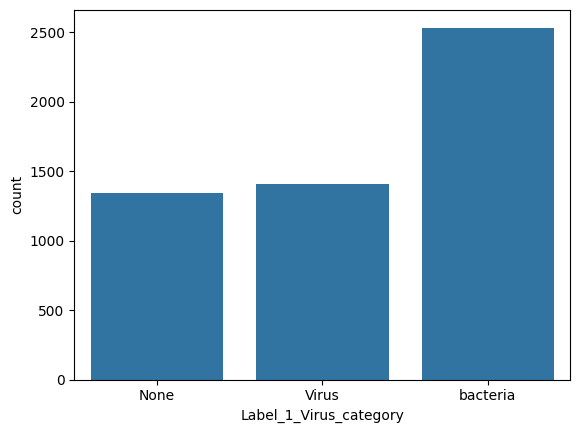

In [34]:
sns.countplot(x = train['Label_1_Virus_category'])
#None = Normal 
#Virus = Pneumonia_Virus 
#Bacteria = Pneumonia_Bacteria

In [ ]:
data_path = Path('train')
img_path_list = list(data_path.glob('*/*.jpeg'))


[]